# Granger Causality

## Global Trends

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_csv('processed-datasets/merged/democracy_wbl_rdi.csv', low_memory=False)

# Polity5 special codes → NaN
polity_cols = ['p_polity2', 'p_democ', 'p_autoc']
for col in polity_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df.loc[df[col] < -10, col] = np.nan

# Normalise p_polity2 from [-10, +10] to [0, 1] for comparability
df['p_polity2_norm'] = (df['p_polity2'] + 10) / 20

# Annual global means (equally weighted across country-years)
yearly = df.groupby('year').agg(
    # Democracy
    polity2_norm   = ('p_polity2_norm', 'mean'),
    polyarchy      = ('v_v2x_polyarchy', 'mean'),
    libdem         = ('v_v2x_libdem', 'mean'),
    # Civil liberties
    frassoc        = ('v_v2x_frassoc_thick', 'mean'),
    freexp         = ('v_v2x_freexp_altinf', 'mean'),
    rule_of_law    = ('v_v2x_rule', 'mean'),
    # Women's rights
    wbl_index_norm = ('wbl_index', lambda x: x.mean() / 100),   # rescale to 0-1
    gender_emp     = ('v_v2x_gender', 'mean'),
    gencl          = ('v_v2x_gencl', 'mean'),
).reset_index()

print(yearly.shape)
yearly.head()

(48, 10)


,year,polity2_norm,polyarchy,libdem,frassoc,freexp,rule_of_law,wbl_index_norm,gender_emp,gencl
0,1971,0.355161,0.270701,0.204109,0.309424,0.331164,0.452403,0.453143,0.436953,0.432395
1,1972,0.339423,0.269266,0.203434,0.301158,0.328559,0.447898,0.455143,0.438273,0.432186
2,1973,0.345223,0.268175,0.201989,0.296305,0.320819,0.444125,0.458143,0.440087,0.432316
3,1974,0.347785,0.267706,0.202657,0.296243,0.324847,0.443977,0.466071,0.451439,0.437136
4,1975,0.348476,0.271497,0.205617,0.298559,0.325034,0.447415,0.470679,0.460305,0.445486


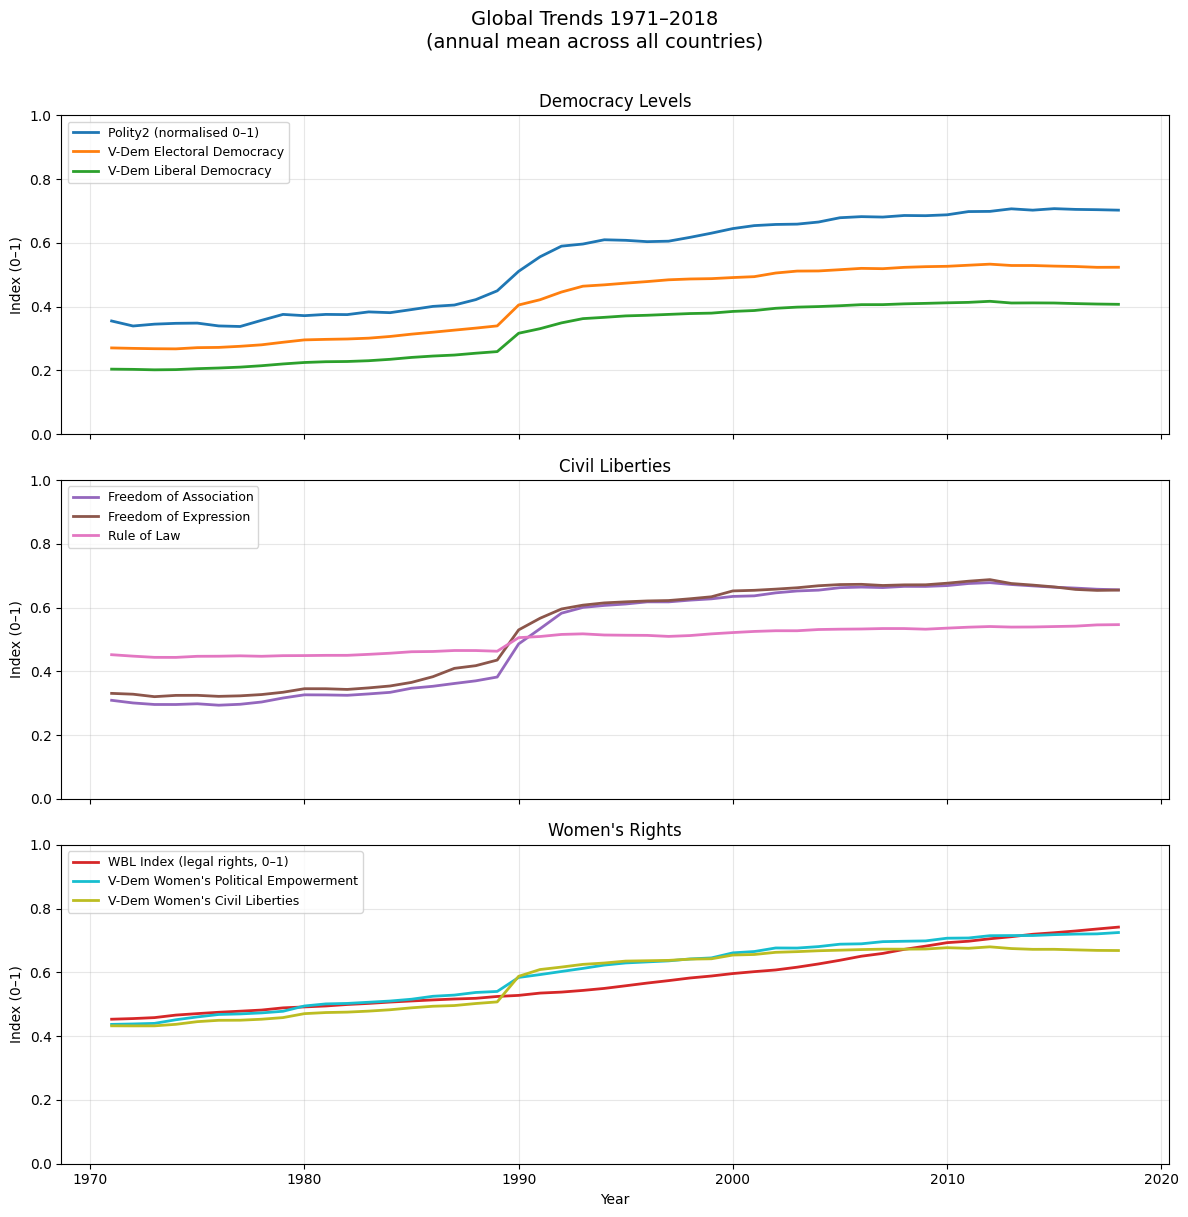

In [2]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
fig.suptitle('Global Trends 1971–2018\n(annual mean across all countries)', fontsize=14, y=1.01)

years = yearly['year']

# ── Panel 1: Democracy ────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(years, yearly['polity2_norm'], label='Polity2 (normalised 0–1)', color='#1f77b4', linewidth=2)
ax.plot(years, yearly['polyarchy'],    label='V-Dem Electoral Democracy',  color='#ff7f0e', linewidth=2)
ax.plot(years, yearly['libdem'],       label='V-Dem Liberal Democracy',    color='#2ca02c', linewidth=2)
ax.set_ylabel('Index (0–1)')
ax.set_title('Democracy Levels')
ax.legend(loc='upper left', fontsize=9)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

# ── Panel 2: Civil Liberties ──────────────────────────────────────────────────
ax = axes[1]
ax.plot(years, yearly['frassoc'],     label='Freedom of Association',     color='#9467bd', linewidth=2)
ax.plot(years, yearly['freexp'],      label='Freedom of Expression',      color='#8c564b', linewidth=2)
ax.plot(years, yearly['rule_of_law'], label='Rule of Law',                color='#e377c2', linewidth=2)
ax.set_ylabel('Index (0–1)')
ax.set_title('Civil Liberties')
ax.legend(loc='upper left', fontsize=9)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

# ── Panel 3: Women's Rights ───────────────────────────────────────────────────
ax = axes[2]
ax.plot(years, yearly['wbl_index_norm'], label='WBL Index (legal rights, 0–1)', color='#d62728', linewidth=2)
ax.plot(years, yearly['gender_emp'],     label="V-Dem Women's Political Empowerment", color='#17becf', linewidth=2)
ax.plot(years, yearly['gencl'],          label="V-Dem Women's Civil Liberties",       color='#bcbd22', linewidth=2)
ax.set_ylabel('Index (0–1)')
ax.set_title("Women's Rights")
ax.legend(loc='upper left', fontsize=9)
ax.set_ylim(0, 1)
ax.set_xlabel('Year')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('global_trends.png', dpi=150, bbox_inches='tight')
plt.show()

## Granger Causality: Democracy / Civil Liberties → WBL Composite Scores

**Approach:**
- Run per-country Granger causality tests using `statsmodels.tsa.stattools.grangercausalitytests`
- **First-difference** both series before testing to address non-stationarity (all indices are trending upward)
- Test lags 1–4 years; for each country-pair use the **minimum p-value across lags** (best lag)
- Require at least 20 non-null observations per country-series pair
- Aggregate across countries: report **% of countries where p < 0.05** and the **Fisher combined p-value**

In [3]:
from statsmodels.tsa.stattools import grangercausalitytests
from scipy import stats
import warnings

MAXLAG  = 4
MIN_OBS = 20   # minimum first-differenced observations per series

predictors = {
    'Polity2':                   'p_polity2_norm',
    'Electoral Democracy':       'v_v2x_polyarchy',
    'Liberal Democracy':         'v_v2x_libdem',
    'Freedom of Association':    'v_v2x_frassoc_thick',
    'Freedom of Expression':     'v_v2x_freexp_altinf',
    'Rule of Law':               'v_v2x_rule',
}

wbl_targets = {
    'WBL Index':        'wbl_index',
    'Mobility':         'mobility',
    'Workplace':        'workplace',
    'Pay':              'pay',
    'Marriage':         'marriage',
    'Parenthood':       'parenthood',
    'Entrepreneurship': 'entrepreneurship',
    'Assets':           'assets',
    'Pension':          'pension',
}

# Collect per-country p-values for each (predictor → target) pair
granger_pvals = {(p, t): [] for p in predictors for t in wbl_targets}

for country, grp in df.groupby('curr_iso3'):
    grp = grp.sort_values('year')
    for pred_name, pred_col in predictors.items():
        for tgt_name, tgt_col in wbl_targets.items():
            pair = grp[[pred_col, tgt_col]].dropna()
            if len(pair) < MIN_OBS + 1:   # +1 because differencing loses one row
                continue
            # First-difference both series
            diff = pair.diff().dropna()
            if len(diff) < MIN_OBS:
                continue
            # Skip if either series has zero variance (no change over time)
            if diff[pred_col].std() == 0 or diff[tgt_col].std() == 0:
                continue
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter('ignore')
                    test = grangercausalitytests(diff[[tgt_col, pred_col]], maxlag=MAXLAG, verbose=False)
                # Min p-value across lags (best lag)
                min_p = min(test[lag][0]['ssr_ftest'][1] for lag in range(1, MAXLAG + 1))
                granger_pvals[(pred_name, tgt_name)].append(min_p)
            except Exception:
                pass

# Aggregate: % significant and Fisher combined p-value
rows = []
for (pred_name, tgt_name), pvals in granger_pvals.items():
    if len(pvals) == 0:
        continue
    pct_sig = np.mean(np.array(pvals) < 0.05) * 100
    # Fisher's method: -2 * sum(log(p)) ~ chi2(2k)
    stat, fisher_p = stats.combine_pvalues(pvals, method='fisher')
    rows.append({
        'Predictor': pred_name,
        'Target': tgt_name,
        'N countries': len(pvals),
        '% significant (p<0.05)': round(pct_sig, 1),
        'Fisher p-value': fisher_p,
        'Median p-value': np.median(pvals),
    })

results_df = pd.DataFrame(rows)
print(f"Tests run. Countries per pair (sample): {results_df['N countries'].describe()}")
results_df.head(12)

Tests run. Countries per pair (sample): count     54.000000
mean     108.796296
std       34.262240
min       45.000000
25%       84.250000
50%      108.000000
75%      138.000000
max      170.000000
Name: N countries, dtype: float64


,Predictor,Target,N countries,% significant (p<0.05),Fisher p-value,Median p-value
0,Polity2,WBL Index,138,22.5,1.110936e-34,0.439192
1,Polity2,Mobility,45,24.4,3.534870e-45,0.820506
2,Polity2,Workplace,123,20.3,6.703583e-34,0.734411
3,Polity2,Pay,86,18.6,9.842934e-17,0.792440
4,Polity2,Marriage,100,18.0,3.888529e-05,0.816346
5,Polity2,Parenthood,112,25.0,4.449502e-110,0.697680
6,Polity2,Entrepreneurship,68,13.2,3.104239e-29,0.823348
7,Polity2,Assets,58,20.7,9.749066e-32,0.835697
8,Polity2,Pension,84,32.1,2.265491e-61,0.757561
9,Electoral Democracy,WBL Index,170,23.5,4.561643e-43,0.380564


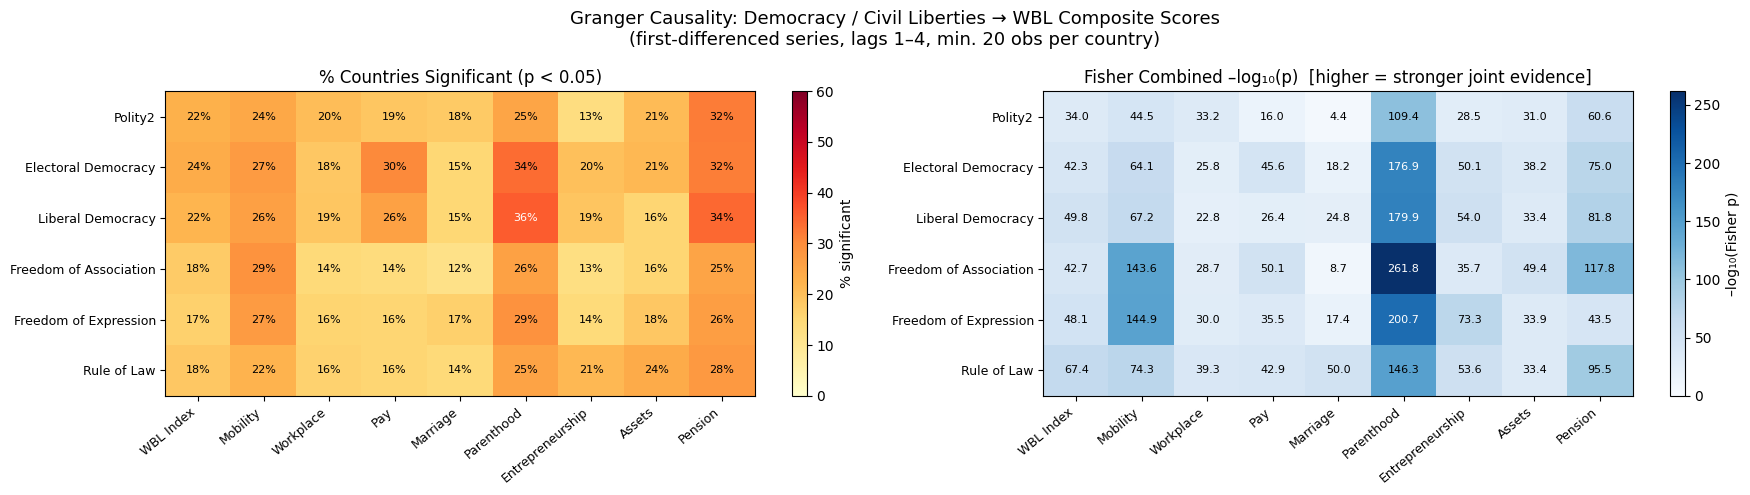

In [4]:
pred_order = list(predictors.keys())
tgt_order  = list(wbl_targets.keys())

# ── Heatmap 1: % of countries with p < 0.05 ──────────────────────────────────
pct_matrix = results_df.pivot(index='Predictor', columns='Target', values='% significant (p<0.05)')
pct_matrix = pct_matrix.reindex(index=pred_order, columns=tgt_order)

# ── Heatmap 2: Fisher combined p-value (–log10 scale) ────────────────────────
fisher_matrix = results_df.pivot(index='Predictor', columns='Target', values='Fisher p-value')
fisher_matrix = fisher_matrix.reindex(index=pred_order, columns=tgt_order)
log_fisher    = -np.log10(fisher_matrix.clip(lower=1e-300))

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle(
    'Granger Causality: Democracy / Civil Liberties → WBL Composite Scores\n'
    '(first-differenced series, lags 1–4, min. 20 obs per country)',
    fontsize=13
)

import matplotlib.colors as mcolors

# Panel A – % countries significant
im1 = axes[0].imshow(pct_matrix.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=60)
axes[0].set_xticks(range(len(tgt_order)))
axes[0].set_xticklabels(tgt_order, rotation=40, ha='right', fontsize=9)
axes[0].set_yticks(range(len(pred_order)))
axes[0].set_yticklabels(pred_order, fontsize=9)
axes[0].set_title('% Countries Significant (p < 0.05)')
for i in range(len(pred_order)):
    for j in range(len(tgt_order)):
        v = pct_matrix.values[i, j]
        if not np.isnan(v):
            axes[0].text(j, i, f'{v:.0f}%', ha='center', va='center', fontsize=8,
                         color='black' if v < 35 else 'white')
plt.colorbar(im1, ax=axes[0], label='% significant')

# Panel B – Fisher combined –log10(p)
im2 = axes[1].imshow(log_fisher.values, aspect='auto', cmap='Blues', vmin=0)
axes[1].set_xticks(range(len(tgt_order)))
axes[1].set_xticklabels(tgt_order, rotation=40, ha='right', fontsize=9)
axes[1].set_yticks(range(len(pred_order)))
axes[1].set_yticklabels(pred_order, fontsize=9)
axes[1].set_title('Fisher Combined –log₁₀(p)  [higher = stronger joint evidence]')
for i in range(len(pred_order)):
    for j in range(len(tgt_order)):
        v = log_fisher.values[i, j]
        if not np.isnan(v):
            axes[1].text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=8,
                         color='black' if v < log_fisher.values.max() * 0.6 else 'white')
plt.colorbar(im2, ax=axes[1], label='–log₁₀(Fisher p)')

plt.tight_layout()
plt.savefig('granger_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

WBL targets ranked by average % of countries significant across all predictors:



,Mean % sig,Max % sig,Best predictor,Mean –log₁₀(p),Max –log₁₀(p)
Target,,,,,
Pension,29.6,34.3,Liberal Democracy,79.1,43.5
Parenthood,29.1,35.8,Liberal Democracy,179.2,109.4
Mobility,25.9,28.6,Freedom of Association,89.8,44.5
WBL Index,20.1,23.5,Electoral Democracy,47.4,34.0
Pay,20.0,30.3,Electoral Democracy,36.1,16.0
Assets,19.2,23.9,Rule of Law,36.5,31.0
Workplace,17.3,20.3,Polity2,30.0,22.8
Entrepreneurship,16.7,21.2,Rule of Law,49.2,28.5
Marriage,15.2,18.0,Polity2,20.6,4.4


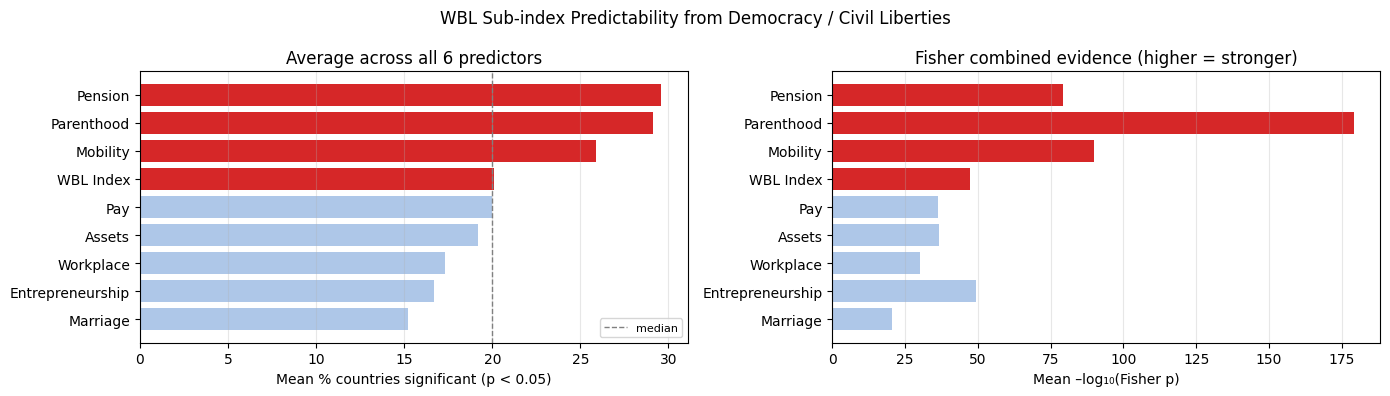

In [5]:
# Aggregate across all predictors to rank WBL targets by predictability
by_target = results_df.groupby('Target').agg(
    mean_pct_sig    = ('% significant (p<0.05)', 'mean'),
    max_pct_sig     = ('% significant (p<0.05)', 'max'),
    best_predictor  = ('% significant (p<0.05)', lambda x: results_df.loc[x.idxmax(), 'Predictor']),
    mean_log_fisher = ('Fisher p-value', lambda x: -np.log10(x.clip(lower=1e-300)).mean()),
    max_log_fisher  = ('Fisher p-value', lambda x: -np.log10(x.clip(lower=1e-300)).max()),
).sort_values('mean_pct_sig', ascending=False).round(1)

by_target.columns = ['Mean % sig', 'Max % sig', 'Best predictor', 'Mean –log₁₀(p)', 'Max –log₁₀(p)']
print("WBL targets ranked by average % of countries significant across all predictors:\n")
display(by_target)

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('WBL Sub-index Predictability from Democracy / Civil Liberties', fontsize=12)

order = by_target.index.tolist()
colors = ['#d62728' if v > by_target['Mean % sig'].median() else '#aec7e8' for v in by_target['Mean % sig']]

axes[0].barh(order[::-1], by_target.loc[order[::-1], 'Mean % sig'], color=colors[::-1])
axes[0].axvline(by_target['Mean % sig'].median(), color='grey', linestyle='--', linewidth=1, label='median')
axes[0].set_xlabel('Mean % countries significant (p < 0.05)')
axes[0].set_title('Average across all 6 predictors')
axes[0].legend(fontsize=8)
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(order[::-1], by_target.loc[order[::-1], 'Mean –log₁₀(p)'], color=colors[::-1])
axes[1].set_xlabel('Mean –log₁₀(Fisher p)')
axes[1].set_title('Fisher combined evidence (higher = stronger)')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('wbl_predictability.png', dpi=150, bbox_inches='tight')
plt.show()

## Reverse Granger Causality: WBL Composite Scores → Democracy / Civil Liberties

Same methodology as above but with roles swapped: testing whether past changes in women's legal rights predict future changes in democracy or civil liberties indicators.

In [6]:
# Reverse direction: WBL sub-indices → democracy / civil liberties
rev_pvals = {(t, p): [] for t in wbl_targets for p in predictors}

for country, grp in df.groupby('curr_iso3'):
    grp = grp.sort_values('year')
    for tgt_name, tgt_col in wbl_targets.items():
        for pred_name, pred_col in predictors.items():
            pair = grp[[pred_col, tgt_col]].dropna()
            if len(pair) < MIN_OBS + 1:
                continue
            diff = pair.diff().dropna()
            if len(diff) < MIN_OBS:
                continue
            if diff[pred_col].std() == 0 or diff[tgt_col].std() == 0:
                continue
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter('ignore')
                    # Note: [target (democracy), predictor (wbl)] — testing WBL → democracy
                    test = grangercausalitytests(diff[[pred_col, tgt_col]], maxlag=MAXLAG, verbose=False)
                min_p = min(test[lag][0]['ssr_ftest'][1] for lag in range(1, MAXLAG + 1))
                rev_pvals[(tgt_name, pred_name)].append(min_p)
            except Exception:
                pass

rev_rows = []
for (tgt_name, pred_name), pvals in rev_pvals.items():
    if len(pvals) == 0:
        continue
    pct_sig = np.mean(np.array(pvals) < 0.05) * 100
    stat, fisher_p = stats.combine_pvalues(pvals, method='fisher')
    rev_rows.append({
        'WBL Predictor': tgt_name,
        'Democracy/CL Target': pred_name,
        'N countries': len(pvals),
        '% significant (p<0.05)': round(pct_sig, 1),
        'Fisher p-value': fisher_p,
        'Median p-value': np.median(pvals),
    })

rev_df = pd.DataFrame(rev_rows)
print(f"Reverse tests run: {len(rev_df)} pairs")
rev_df.head(12)

Reverse tests run: 54 pairs


,WBL Predictor,Democracy/CL Target,N countries,% significant (p<0.05),Fisher p-value,Median p-value
0,WBL Index,Polity2,138,13.0,6.218643e-10,0.614918
1,WBL Index,Electoral Democracy,170,15.9,4.227321e-18,0.427717
2,WBL Index,Liberal Democracy,168,16.1,3.130036e-15,0.385524
3,WBL Index,Freedom of Association,170,13.5,1.442513e-24,0.525522
4,WBL Index,Freedom of Expression,169,13.6,1.144295e-09,0.490869
5,WBL Index,Rule of Law,169,10.7,3.593396e-07,0.546436
6,Mobility,Polity2,46,21.7,6.550993e-37,0.854704
7,Mobility,Electoral Democracy,65,18.5,7.063386e-23,0.594942
8,Mobility,Liberal Democracy,63,14.3,1.078584e-15,0.465820
9,Mobility,Freedom of Association,65,18.5,1.002179e-53,0.669039


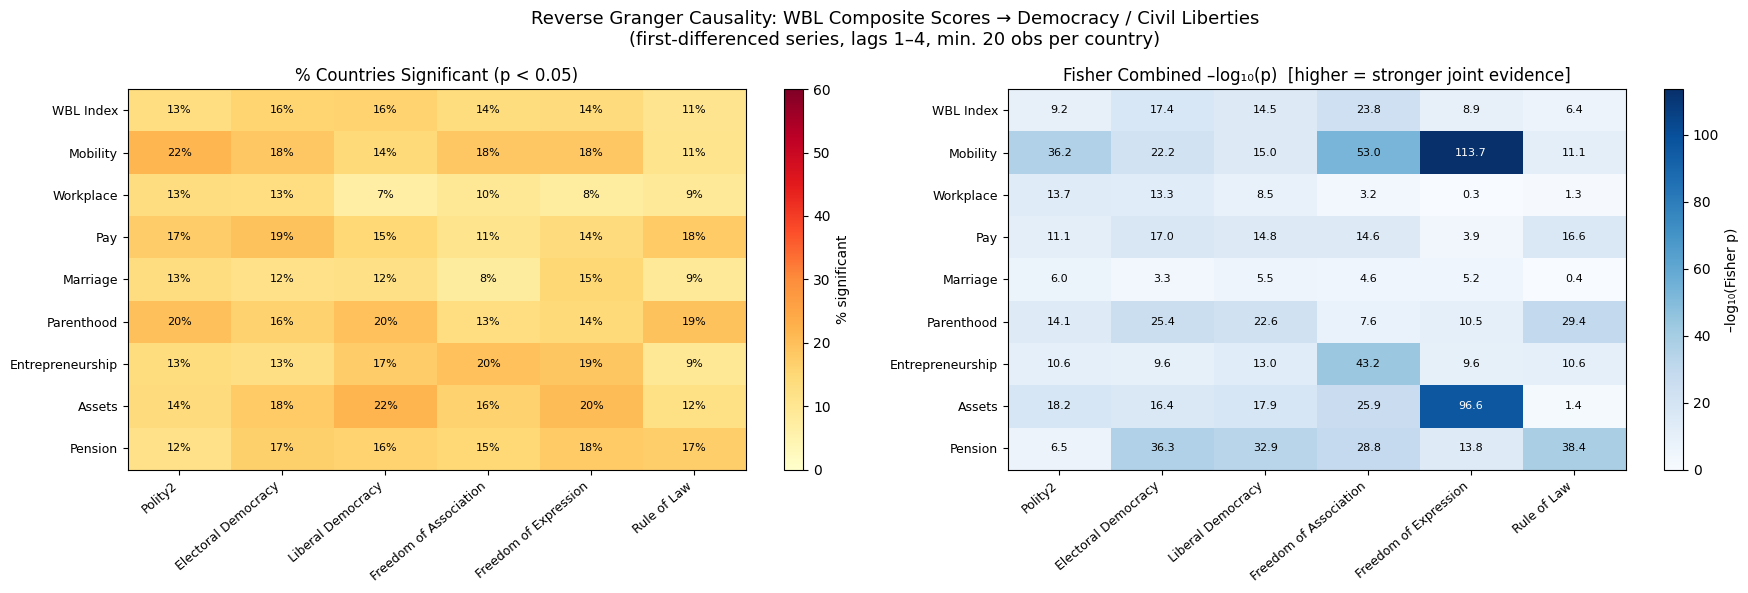

In [7]:
dem_order = list(predictors.keys())
wbl_order  = list(wbl_targets.keys())

pct_rev   = rev_df.pivot(index='WBL Predictor', columns='Democracy/CL Target', values='% significant (p<0.05)')
pct_rev   = pct_rev.reindex(index=wbl_order, columns=dem_order)

fisher_rev     = rev_df.pivot(index='WBL Predictor', columns='Democracy/CL Target', values='Fisher p-value')
fisher_rev     = fisher_rev.reindex(index=wbl_order, columns=dem_order)
log_fisher_rev = -np.log10(fisher_rev.clip(lower=1e-300))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(
    'Reverse Granger Causality: WBL Composite Scores → Democracy / Civil Liberties\n'
    '(first-differenced series, lags 1–4, min. 20 obs per country)',
    fontsize=13
)

im1 = axes[0].imshow(pct_rev.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=60)
axes[0].set_xticks(range(len(dem_order)))
axes[0].set_xticklabels(dem_order, rotation=40, ha='right', fontsize=9)
axes[0].set_yticks(range(len(wbl_order)))
axes[0].set_yticklabels(wbl_order, fontsize=9)
axes[0].set_title('% Countries Significant (p < 0.05)')
for i in range(len(wbl_order)):
    for j in range(len(dem_order)):
        v = pct_rev.values[i, j]
        if not np.isnan(v):
            axes[0].text(j, i, f'{v:.0f}%', ha='center', va='center', fontsize=8,
                         color='black' if v < 35 else 'white')
plt.colorbar(im1, ax=axes[0], label='% significant')

im2 = axes[1].imshow(log_fisher_rev.values, aspect='auto', cmap='Blues', vmin=0)
axes[1].set_xticks(range(len(dem_order)))
axes[1].set_xticklabels(dem_order, rotation=40, ha='right', fontsize=9)
axes[1].set_yticks(range(len(wbl_order)))
axes[1].set_yticklabels(wbl_order, fontsize=9)
axes[1].set_title('Fisher Combined –log₁₀(p)  [higher = stronger joint evidence]')
for i in range(len(wbl_order)):
    for j in range(len(dem_order)):
        v = log_fisher_rev.values[i, j]
        if not np.isnan(v):
            axes[1].text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=8,
                         color='black' if v < log_fisher_rev.values.max() * 0.6 else 'white')
plt.colorbar(im2, ax=axes[1], label='–log₁₀(Fisher p)')

plt.tight_layout()
plt.savefig('granger_reverse_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Rank democracy/CL targets by how predictable they are from WBL
by_dem_target = rev_df.groupby('Democracy/CL Target').agg(
    mean_pct_sig    = ('% significant (p<0.05)', 'mean'),
    max_pct_sig     = ('% significant (p<0.05)', 'max'),
    best_wbl        = ('% significant (p<0.05)', lambda x: rev_df.loc[x.idxmax(), 'WBL Predictor']),
    mean_log_fisher = ('Fisher p-value', lambda x: -np.log10(x.clip(lower=1e-300)).mean()),
).sort_values('mean_pct_sig', ascending=False).round(1)

by_dem_target.columns = ['Mean % sig', 'Max % sig', 'Best WBL predictor', 'Mean –log₁₀(p)']

# Rank WBL sub-indices by how much they predict democracy/CL
by_wbl_pred = rev_df.groupby('WBL Predictor').agg(
    mean_pct_sig    = ('% significant (p<0.05)', 'mean'),
    max_pct_sig     = ('% significant (p<0.05)', 'max'),
    best_dem        = ('% significant (p<0.05)', lambda x: rev_df.loc[x.idxmax(), 'Democracy/CL Target']),
    mean_log_fisher = ('Fisher p-value', lambda x: -np.log10(x.clip(lower=1e-300)).mean()),
).sort_values('mean_pct_sig', ascending=False).round(1)

by_wbl_pred.columns = ['Mean % sig', 'Max % sig', 'Best democracy target', 'Mean –log₁₀(p)']

print("Democracy/CL targets ranked by predictability from WBL:\n")
display(by_dem_target)
print("\nWBL sub-indices ranked by predictive power over democracy/CL:\n")
display(by_wbl_pred)

Democracy/CL targets ranked by predictability from WBL:



,Mean % sig,Max % sig,Best WBL predictor,Mean –log₁₀(p)
Democracy/CL Target,,,,
Electoral Democracy,15.8,19.3,Pay,17.9
Freedom of Expression,15.6,20.5,Assets,29.2
Liberal Democracy,15.4,21.9,Assets,16.1
Polity2,15.3,21.7,Mobility,14.0
Freedom of Association,13.8,19.5,Entrepreneurship,22.8
Rule of Law,12.7,19.4,Parenthood,12.8



WBL sub-indices ranked by predictive power over democracy/CL:



,Mean % sig,Max % sig,Best democracy target,Mean –log₁₀(p)
WBL Predictor,,,,
Parenthood,17.1,19.8,Polity2,18.3
Mobility,17.0,21.7,Polity2,41.8
Assets,17.0,21.9,Liberal Democracy,29.4
Pension,15.7,17.8,Freedom of Expression,26.1
Pay,15.7,19.3,Electoral Democracy,13.0
Entrepreneurship,15.1,19.5,Freedom of Association,16.1
WBL Index,13.8,16.1,Liberal Democracy,13.4
Marriage,11.5,15.2,Freedom of Expression,4.2
Workplace,9.8,13.2,Polity2,6.7


### Simple Granger Causality